# Fraud Detection: Identifying Fraudulent Credit Card Transactions

**Author:** Hamza Al Habash
**Context:** Deloitte case study, August 2026

## Objective
Build and evaluate a model that classifies credit card transactions as fraudulent (1) or benign (0),
then translate the result into a decision the business can actually operate.

## Contents
1. Load and audit the data
2. Exploratory data analysis
3. Feature engineering
4. Train / test split (temporal) and a leakage check
5. Model selection and baselines
6. Class imbalance strategies
7. Hyperparameter tuning
8. Threshold selection driven by cost, not by accuracy
9. Model interpretation
10. Business outcomes and recommendations
11. Saved artifacts

## Headline framing
The dataset is severely imbalanced (about 1.2% fraud). Accuracy is not a usable metric here:
predicting "never fraud" scores 98.8% accuracy and catches nothing. The primary metric in this
notebook is **PR-AUC (average precision)**, supported by recall at a business-chosen operating
threshold. ROC-AUC is reported for completeness but is optimistically biased under this level of
imbalance.

In [1]:
!pip install -q xgboost lightgbm imbalanced-learn shap

In [2]:
# ---- Environment and configuration -------------------------------------------------
import json, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = "fraud.csv"          # adjust if the CSV lives elsewhere
SPLIT_STEP = 144                 # temporal cut: steps < 144 train, >= 144 test (see section 4)
REVIEW_COST = 5.0                # cost in currency units of manually reviewing one alert
N_SEARCH_ITER = 15               # random search budget

OUT_DIR, FIG_DIR = "outputs", "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True, "axes.titleweight": "bold"})

np.random.seed(RANDOM_STATE)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 2.0.2


## 1. Load and audit the data

In [3]:
# Every string field in this file is wrapped in literal single quotes ('C1093826151'),
# so the quotes are stripped at load time. Downcasting step and amount keeps memory low.
t0 = time.time()
df = pd.read_csv(DATA_PATH, dtype={"step": "int16", "amount": "float32"})

STR_COLS = ["customer", "age", "gender", "zipcodeOri", "merchant", "zipMerchant", "category"]
for c in STR_COLS:
    df[c] = df[c].str.strip("'")

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns in {time.time()-t0:.1f}s")
df.head()

Loaded 594,643 rows x 10 columns in 3.1s


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.550000,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.680000,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.889999,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.250000,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.720001,0


In [4]:
# ---- Data audit --------------------------------------------------------------------
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "n_unique": df.nunique(),
    "example": df.iloc[0],
})
print(audit.to_string())
print(f"\nExact duplicate rows: {df.duplicated().sum():,}")
print(f"Time span: step {df.step.min()} to {df.step.max()} "
      f"({(df.step.max()+1)/24:.1f} days at 1 step = 1 hour)")

               dtype  nulls  n_unique            example
step           int16      0       180                  0
customer      object      0      4112        C1093826151
age           object      0         8                  4
gender        object      0         4                  M
zipcodeOri    object      0         1              28007
merchant      object      0        50         M348934600
zipMerchant   object      0         1              28007
category      object      0        15  es_transportation
amount       float32      0     23767               4.55
fraud          int64      0         2                  0

Exact duplicate rows: 0
Time span: step 0 to 179 (7.5 days at 1 step = 1 hour)


In [5]:
# ---- Drop zero-information columns -------------------------------------------------
# zipcodeOri and zipMerchant each hold a single constant value across all 594k rows,
# so they carry no signal and are removed rather than encoded.
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Constant columns detected:", constant_cols)

df = df.drop(columns=constant_cols)
print("Remaining columns:", list(df.columns))

Constant columns detected: ['zipcodeOri', 'zipMerchant']
Remaining columns: ['step', 'customer', 'age', 'gender', 'merchant', 'category', 'amount', 'fraud']


## 2. Exploratory data analysis

The questions worth answering before modelling: how skewed is the target, does amount separate the
classes, and is fraud concentrated in a subset of categories or merchants? The answers determine both
the metric and the feature set.

Benign : 587,443
Fraud  : 7,200
Fraud rate: 1.2108%
Imbalance ratio: 1 fraud per 82 benign transactions

A 'predict never fraud' model would score 98.79% accuracy and catch 0 fraud cases.


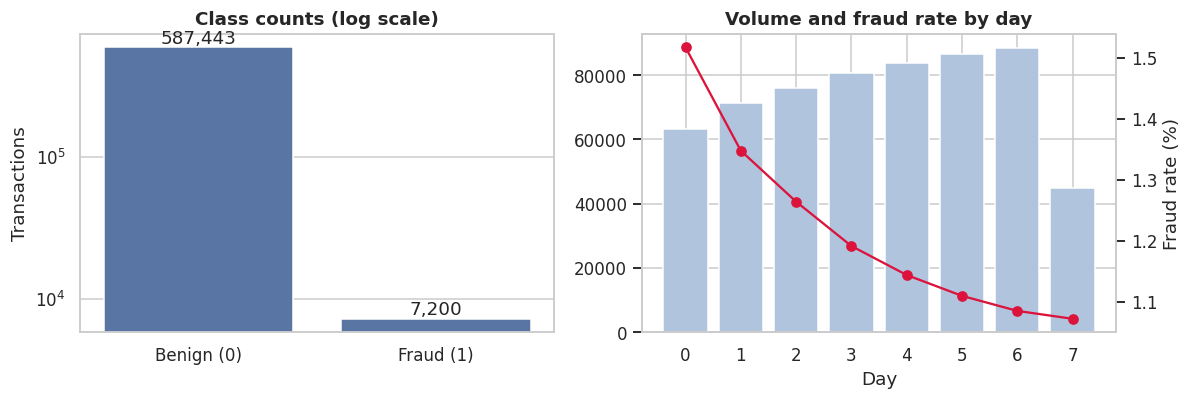

In [6]:
# ---- Target distribution -----------------------------------------------------------
counts = df.fraud.value_counts().sort_index()
rate = df.fraud.mean()
print(f"Benign : {counts[0]:,}\nFraud  : {counts[1]:,}\nFraud rate: {rate:.4%}")
print(f"Imbalance ratio: 1 fraud per {counts[0]/counts[1]:.0f} benign transactions")
print(f"\nA 'predict never fraud' model would score {1-rate:.2%} accuracy and catch 0 fraud cases.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.barplot(x=["Benign (0)", "Fraud (1)"], y=counts.values, ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Class counts (log scale)"); ax[0].set_ylabel("Transactions")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

daily = df.groupby(df.step // 24).fraud.agg(["count", "mean"])
ax[1].bar(daily.index, daily["count"], color="lightsteelblue", label="Transactions")
ax2 = ax[1].twinx()
ax2.plot(daily.index, daily["mean"]*100, color="crimson", marker="o", label="Fraud rate %")
ax[1].set_xlabel("Day"); ax[1].set_title("Volume and fraud rate by day")
ax2.set_ylabel("Fraud rate (%)"); ax2.grid(False)
plt.savefig(f"{FIG_DIR}/01_class_balance.png", bbox_inches="tight"); plt.show()

          count        mean         std   min         25%         50%         75%          max
fraud                                                                                         
0      587443.0   31.847229   31.465965  0.00   13.590000   26.610001   41.895000  2144.860107
1        7200.0  530.926514  835.586853  0.03  159.979996  319.175003  548.977524  8329.959961


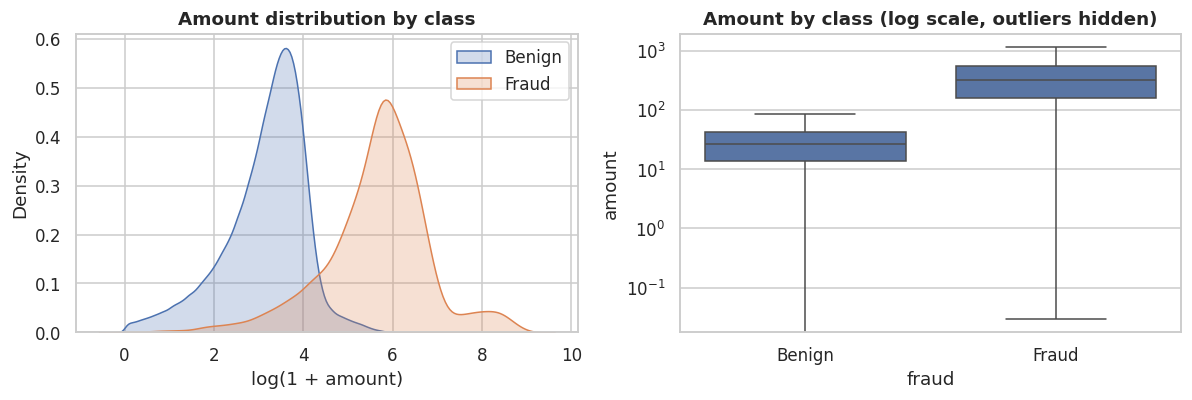


Median fraudulent amount is 12.0x the median benign amount.


In [7]:
# ---- Amount: the strongest numeric signal ------------------------------------------
print(df.groupby("fraud").amount.describe().to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for label, name in [(0, "Benign"), (1, "Fraud")]:
    sns.kdeplot(np.log1p(df.loc[df.fraud == label, "amount"]), ax=ax[0], fill=True, label=name)
ax[0].set_xlabel("log(1 + amount)"); ax[0].set_title("Amount distribution by class"); ax[0].legend()

sns.boxplot(data=df, x="fraud", y="amount", ax=ax[1], showfliers=False)
ax[1].set_yscale("log"); ax[1].set_title("Amount by class (log scale, outliers hidden)")
ax[1].set_xticklabels(["Benign", "Fraud"])
plt.savefig(f"{FIG_DIR}/02_amount.png", bbox_inches="tight"); plt.show()

print(f"\nMedian fraudulent amount is {df[df.fraud==1].amount.median()/df[df.fraud==0].amount.median():.1f}x "
      f"the median benign amount.")

                       transactions  fraud_cases fraud_rate  median_amount
category                                                                  
es_leisure                      499          474     94.99%     296.660004
es_travel                       728          578     79.40%    1888.459961
es_sportsandtoys               4002         1982     49.53%     134.175003
es_hotelservices               1744          548     31.42%     131.940002
es_otherservices                912          228     25.00%      87.279999
es_home                        1986          302     15.21%     111.309998
es_health                     16133         1696     10.51%      97.889999
es_tech                        2370          158      6.67%      90.389999
es_wellnessandbeauty          15086          718      4.76%      51.895000
es_hyper                       6098          280      4.59%      36.750000
es_barsandrestaurants          6373          120      1.88%      36.270000
es_fashion               

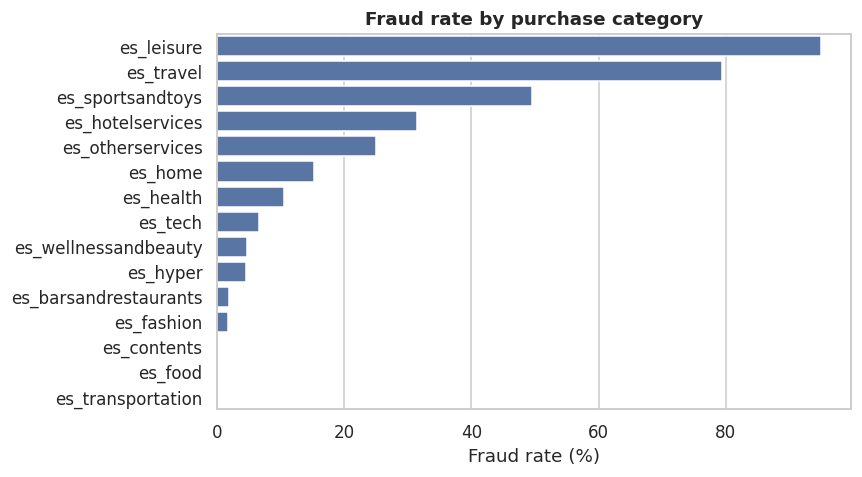

In [8]:
# ---- Category is the dominant categorical signal -----------------------------------
cat_stats = (df.groupby("category")
               .agg(transactions=("fraud", "size"), fraud_cases=("fraud", "sum"),
                    fraud_rate=("fraud", "mean"), median_amount=("amount", "median"))
               .sort_values("fraud_rate", ascending=False))
print(cat_stats.to_string(formatters={"fraud_rate": "{:.2%}".format}))

zero_fraud = cat_stats[cat_stats.fraud_cases == 0]
print(f"\n{len(zero_fraud)} categories contain zero fraud and account for "
      f"{zero_fraud.transactions.sum()/len(df):.1%} of all transactions.")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(y=cat_stats.index, x=cat_stats.fraud_rate*100, ax=ax)
ax.set_xlabel("Fraud rate (%)"); ax.set_ylabel(""); ax.set_title("Fraud rate by purchase category")
plt.savefig(f"{FIG_DIR}/03_category.png", bbox_inches="tight"); plt.show()

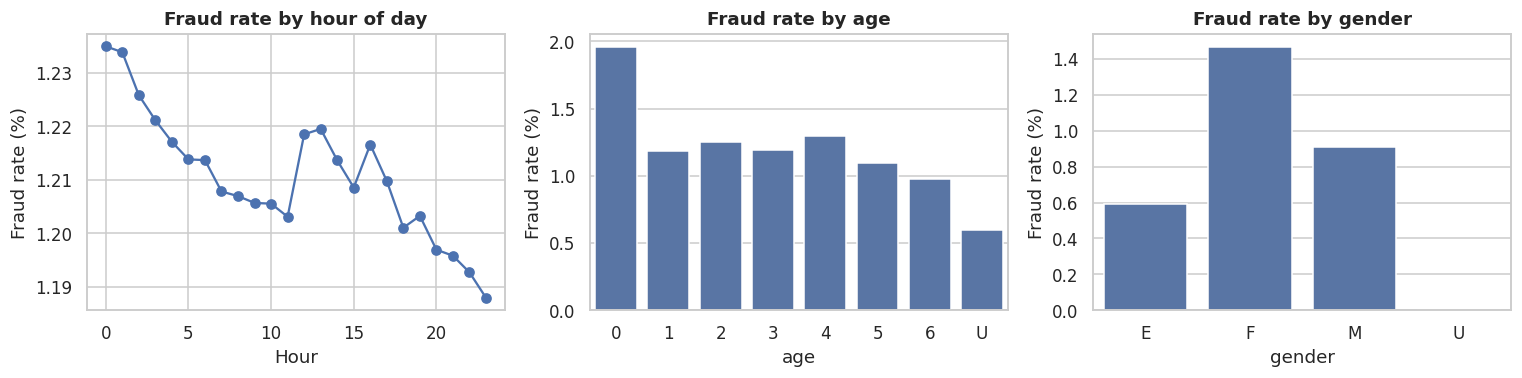

     transactions fraud_rate
age                         
0            2452      1.96%
1           58131      1.19%
2          187310      1.25%
3          147131      1.19%
4          109025      1.29%
5           62642      1.10%
6           26774      0.97%
U            1178      0.59%

        transactions fraud_rate
gender                         
E               1178      0.59%
F             324565      1.47%
M             268385      0.91%
U                515      0.00%


In [9]:
# ---- Time of day, age, gender ------------------------------------------------------
df["hour"] = (df.step % 24).astype("int8")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
h = df.groupby("hour").fraud.agg(["mean", "size"])
ax[0].plot(h.index, h["mean"]*100, marker="o")
ax[0].set_title("Fraud rate by hour of day"); ax[0].set_xlabel("Hour"); ax[0].set_ylabel("Fraud rate (%)")

for i, col in enumerate(["age", "gender"], start=1):
    s = df.groupby(col).fraud.agg(["mean", "size"]).sort_index()
    sns.barplot(x=s.index, y=s["mean"]*100, ax=ax[i])
    ax[i].set_title(f"Fraud rate by {col}"); ax[i].set_ylabel("Fraud rate (%)")
plt.savefig(f"{FIG_DIR}/04_time_demo.png", bbox_inches="tight"); plt.show()

print(df.groupby("age").fraud.agg(transactions="size", fraud_rate="mean").to_string(
      formatters={"fraud_rate": "{:.2%}".format}))
print()
print(df.groupby("gender").fraud.agg(transactions="size", fraud_rate="mean").to_string(
      formatters={"fraud_rate": "{:.2%}".format}))

In [10]:
# ---- Merchant concentration --------------------------------------------------------
m = (df.groupby("merchant")
       .agg(transactions=("fraud", "size"), fraud_cases=("fraud", "sum"), fraud_rate=("fraud", "mean"))
       .sort_values("fraud_cases", ascending=False))
print(f"{df.merchant.nunique()} merchants, {df.customer.nunique():,} customers")
print(f"Top 10 merchants by fraud volume hold {m.head(10).fraud_cases.sum()/df.fraud.sum():.1%} of all fraud\n")
print(m.head(10).to_string(formatters={"fraud_rate": "{:.2%}".format}))

50 merchants, 4,112 customers
Top 10 merchants by fraud volume hold 74.9% of all fraud

             transactions  fraud_cases fraud_rate
merchant                                         
M480139044           3508         1634     46.58%
M980657600           1769         1472     83.21%
M732195782            608          518     85.20%
M1198415165          1580          358     22.66%
M3697346              308          290     94.16%
M855959430           6098          280      4.59%
M1888755466           912          228     25.00%
M1873032707           250          216     86.40%
M2122776122           341          200     58.65%
M1741626453           528          196     37.12%


## 3. Feature engineering

Three families of features are added, and one obvious candidate is deliberately rejected.

**Added**
- `hour = step % 24`, a cyclical time-of-day signal.
- `log_amount`, since amount spans four orders of magnitude.
- Behavioural baselines per customer and per merchant (mean amount, transaction count, spend
  volatility) plus the ratio and z-score of the current amount against those baselines. Fraud is
  usually an amount that is unusual *for that customer*, not just large in absolute terms.

**Rejected:** `day = step // 24`. The temporal split means days 6 and 7 never appear in training,
so a tree would have no split point for them. Time of day generalises; a raw day index does not.

**Leakage control:** all aggregates are computed from the training window only, then mapped onto the
test set. Customers and merchants unseen in training fall back to the global training mean.

In [11]:
def fit_aggregates(train_df):
    """Learn customer- and merchant-level behavioural baselines from the training window only."""
    cust = train_df.groupby("customer").amount.agg(
        cust_amt_mean="mean", cust_amt_std="std", cust_txn_n="count")
    merch = train_df.groupby("merchant").amount.agg(
        merch_amt_mean="mean", merch_txn_n="count")
    return {"cust": cust, "merch": merch, "global_mean": float(train_df.amount.mean())}


def apply_aggregates(frame, agg):
    """Attach the learned baselines and derive relative-spend features."""
    d = frame.join(agg["cust"], on="customer").join(agg["merch"], on="merchant")
    g = agg["global_mean"]
    d["cust_amt_mean"] = d.cust_amt_mean.fillna(g)
    d["cust_amt_std"] = d.cust_amt_std.fillna(0)
    d["cust_txn_n"] = d.cust_txn_n.fillna(0)
    d["merch_amt_mean"] = d.merch_amt_mean.fillna(g)
    d["merch_txn_n"] = d.merch_txn_n.fillna(0)

    d["log_amount"] = np.log1p(d.amount)
    d["amt_ratio_cust"] = d.amount / (d.cust_amt_mean + 1)      # spend vs own habit
    d["amt_ratio_merch"] = d.amount / (d.merch_amt_mean + 1)     # spend vs merchant norm
    d["amt_z_cust"] = (d.amount - d.cust_amt_mean) / (d.cust_amt_std + 1)
    return d


NUM_FEATURES = ["amount", "log_amount", "hour",
                "cust_amt_mean", "cust_amt_std", "cust_txn_n",
                "merch_amt_mean", "merch_txn_n",
                "amt_ratio_cust", "amt_ratio_merch", "amt_z_cust"]
CAT_FEATURES = ["category", "merchant", "age", "gender"]
print("Numeric features :", NUM_FEATURES)
print("Categorical (one-hot):", CAT_FEATURES)

Numeric features : ['amount', 'log_amount', 'hour', 'cust_amt_mean', 'cust_amt_std', 'cust_txn_n', 'merch_amt_mean', 'merch_txn_n', 'amt_ratio_cust', 'amt_ratio_merch', 'amt_z_cust']
Categorical (one-hot): ['category', 'merchant', 'age', 'gender']


## 4. Train / test split

`step` is a clock, so the split is temporal: the model trains on days 0 to 5 and is tested on days 6
and 7. This mirrors production, where a model scores transactions that have not happened yet. A
random split would let the model learn from future transactions of the same customers, which
inflates the score without improving real performance. Section 5 quantifies that inflation.

In [12]:
train_raw = df[df.step < SPLIT_STEP].copy()
test_raw = df[df.step >= SPLIT_STEP].copy()

agg = fit_aggregates(train_raw)
train = apply_aggregates(train_raw, agg)
test = apply_aggregates(test_raw, agg)

def encode(frame, columns=None):
    """One-hot the categoricals and align to a reference column order."""
    X = pd.get_dummies(frame[NUM_FEATURES + CAT_FEATURES], columns=CAT_FEATURES)
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0)
    return X.astype("float32")

X_train = encode(train)
X_test = encode(test, columns=X_train.columns)
y_train, y_test = train.fraud.values, test.fraud.values
FEATURE_NAMES = list(X_train.columns)

print(f"Train: {X_train.shape[0]:,} rows (days 0-5), fraud rate {y_train.mean():.3%}, "
      f"{y_train.sum():,} fraud cases")
print(f"Test : {X_test.shape[0]:,} rows (days 6-7), fraud rate {y_test.mean():.3%}, "
      f"{y_test.sum():,} fraud cases")
print(f"Feature matrix width: {X_train.shape[1]}")

Train: 461,412 rows (days 0-5), fraud rate 1.248%, 5,760 fraud cases
Test : 133,231 rows (days 6-7), fraud rate 1.081%, 1,440 fraud cases
Feature matrix width: 88


## 5. Leakage check: what a random split would have told us

This cell fits the same model twice, once on the temporal split and once on a random stratified
split whose aggregates are computed over the whole dataset. The gap is the size of the optimism a
random split would have introduced. The temporal number is the one reported everywhere else.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import xgboost as xgb

SPW = (y_train == 0).sum() / (y_train == 1).sum()   # scale_pos_weight

def quick_xgb(**kw):
    params = dict(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                  colsample_bytree=0.8, eval_metric="aucpr", tree_method="hist",
                  n_jobs=-1, random_state=RANDOM_STATE)
    params.update(kw)
    return xgb.XGBClassifier(**params)

# Leaky version: aggregates fitted on all data, rows shuffled across time
leaky = apply_aggregates(df.copy(), fit_aggregates(df))
Xl = encode(leaky, columns=FEATURE_NAMES); yl = leaky.fraud.values
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    Xl, yl, test_size=0.225, stratify=yl, random_state=RANDOM_STATE)

m_leak = quick_xgb(scale_pos_weight=SPW).fit(Xl_tr, yl_tr)
m_time = quick_xgb(scale_pos_weight=SPW).fit(X_train, y_train)

ap_leak = average_precision_score(yl_te, m_leak.predict_proba(Xl_te)[:, 1])
ap_time = average_precision_score(y_test, m_time.predict_proba(X_test)[:, 1])
print(f"Random split (leaky)   PR-AUC = {ap_leak:.4f}")
print(f"Temporal split (honest) PR-AUC = {ap_time:.4f}")
print(f"Optimism introduced by a random split: {ap_leak-ap_time:+.4f}")

del leaky, Xl, Xl_tr, Xl_te, m_leak

Random split (leaky)   PR-AUC = 0.9339
Temporal split (honest) PR-AUC = 0.9226
Optimism introduced by a random split: +0.0113


## 6. Model selection and baselines

Four candidates, from interpretable to high capacity:

| Model | Why it is in the shortlist |
|---|---|
| Logistic Regression | Transparent baseline; if a linear model is close, complexity is not justified |
| Random Forest | Handles interactions, robust with little tuning |
| XGBoost | Usually the strongest performer on tabular fraud data |
| LightGBM | Comparable accuracy, faster to train and retrain |

All four are given imbalance-aware settings (`class_weight` or `scale_pos_weight`) so the comparison
is fair. Metrics: PR-AUC as primary, ROC-AUC for reference, and the best achievable F1 with the
threshold that produces it.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve
import lightgbm as lgb

results, curves, models = [], {}, {}

def evaluate(name, y_true, scores, store=True, fit_seconds=None):
    """Score a model on imbalance-appropriate metrics and record the PR curve."""
    ap = average_precision_score(y_true, scores)
    roc = roc_auc_score(y_true, scores)
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    i = int(np.nanargmax(f1))
    row = {"model": name, "PR_AUC": ap, "ROC_AUC": roc, "best_F1": f1[i],
           "precision_at_best_F1": prec[i], "recall_at_best_F1": rec[i],
           "threshold_at_best_F1": thr[min(i, len(thr) - 1)],
           "fit_seconds": fit_seconds}
    if store:
        results.append(row)
        curves[name] = (rec, prec, ap)
    print(f"{name:<22} PR-AUC {ap:.4f} | ROC-AUC {roc:.4f} | best F1 {f1[i]:.4f} "
          f"(P {prec[i]:.3f} / R {rec[i]:.3f})")
    return row

def fit_and_score(name, model):
    t = time.time()
    model.fit(X_train, y_train)
    secs = time.time() - t
    models[name] = model
    evaluate(name, y_test, model.predict_proba(X_test)[:, 1], fit_seconds=round(secs, 1))
    return model

fit_and_score("Logistic Regression", make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)))

fit_and_score("Random Forest", RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))

fit_and_score("XGBoost", quick_xgb(n_estimators=400, scale_pos_weight=SPW))

fit_and_score("LightGBM", lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.1, num_leaves=63, scale_pos_weight=SPW,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))

Logistic Regression    PR-AUC 0.8778 | ROC-AUC 0.9945 | best F1 0.8096 (P 0.797 / R 0.822)
Random Forest          PR-AUC 0.9249 | ROC-AUC 0.9987 | best F1 0.8445 (P 0.846 / R 0.843)
XGBoost                PR-AUC 0.9206 | ROC-AUC 0.9986 | best F1 0.8424 (P 0.861 / R 0.824)
LightGBM               PR-AUC 0.9138 | ROC-AUC 0.9978 | best F1 0.8276 (P 0.839 / R 0.817)


LGBMClassifier(n_estimators=400, n_jobs=-1, num_leaves=63, random_state=42,
               scale_pos_weight=np.float64(79.10625), verbose=-1)

,model,PR_AUC,ROC_AUC,best_F1,precision_at_best_F1,recall_at_best_F1,threshold_at_best_F1,fit_seconds
0,Random Forest,0.9249,0.9987,0.8445,0.846,0.843,0.624,135.200000
1,XGBoost,0.9206,0.9986,0.8424,0.861,0.824,0.862,47.500000
2,LightGBM,0.9138,0.9978,0.8276,0.839,0.817,0.706,18.600000
3,Logistic Regression,0.8778,0.9945,0.8096,0.797,0.822,0.947,20.000000


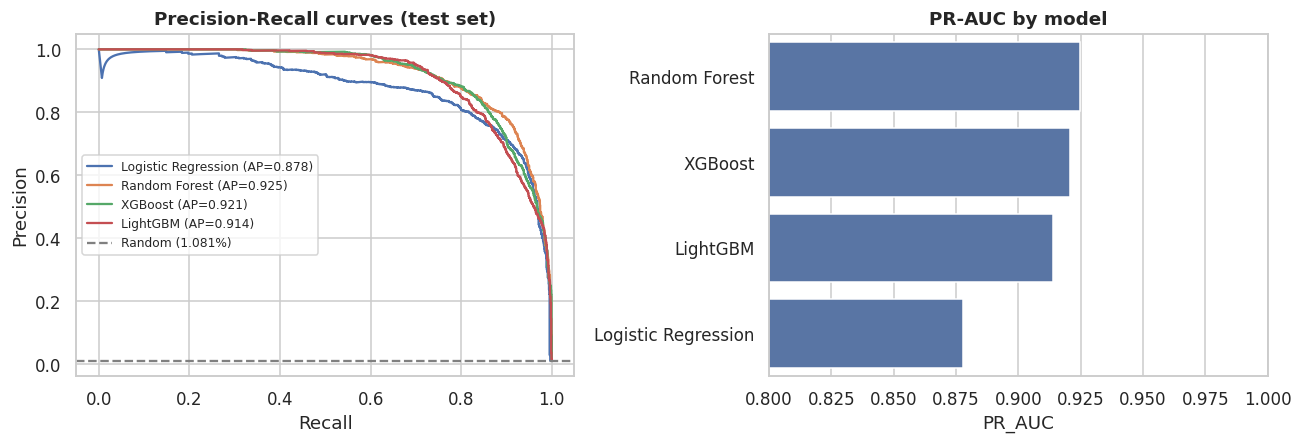

Best baseline: Random Forest


In [15]:
# ---- Comparison table and PR curves ------------------------------------------------
comparison = pd.DataFrame(results).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
display(comparison.style.format({
    "PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "best_F1": "{:.4f}",
    "precision_at_best_F1": "{:.3f}", "recall_at_best_F1": "{:.3f}",
    "threshold_at_best_F1": "{:.3f}"}).background_gradient(subset=["PR_AUC"], cmap="Greens"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for name, (rec, prec, ap) in curves.items():
    ax[0].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
ax[0].axhline(y_test.mean(), ls="--", c="grey", label=f"Random ({y_test.mean():.3%})")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Precision-Recall curves (test set)"); ax[0].legend(fontsize=8)

sns.barplot(data=comparison, y="model", x="PR_AUC", ax=ax[1])
ax[1].set_xlim(0.8, 1.0); ax[1].set_title("PR-AUC by model"); ax[1].set_ylabel("")
plt.savefig(f"{FIG_DIR}/05_model_comparison.png", bbox_inches="tight"); plt.show()

BEST_NAME = comparison.model.iloc[0]
print("Best baseline:", BEST_NAME)

## 7. Class imbalance strategies

The brief suggests SMOTE. It is worth testing rather than assuming: synthetic minority
oversampling interpolates between fraud cases, which can blur an already well-separated boundary,
and it triples training data volume. Four configurations are compared on the same architecture.

**Critical:** resampling is applied to the training set only. Oversampling before the split, or
resampling the test set, produces meaningless scores.

In [16]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

imbalance_rows = []

def imbalance_trial(label, X, y, **kw):
    t = time.time()
    m = quick_xgb(n_estimators=400, **kw).fit(X, y)
    secs = time.time() - t
    row = evaluate(label, y_test, m.predict_proba(X_test)[:, 1], store=False,
                   fit_seconds=round(secs, 1))
    row["train_rows"] = len(y); row["train_fraud_rate"] = float(np.mean(y))
    imbalance_rows.append(row)
    return m

# 1. No correction at all
imbalance_trial("No correction", X_train, y_train)

# 2. Cost-sensitive learning (reweights the loss, no new rows)
m_spw = imbalance_trial("scale_pos_weight", X_train, y_train, scale_pos_weight=SPW)

# 3. SMOTE to a 1:10 minority ratio
Xs, ys = SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_STATE).fit_resample(X_train, y_train)
imbalance_trial("SMOTE (0.1)", Xs, ys)

# 4. SMOTE followed by majority undersampling
Xu, yu = RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE).fit_resample(Xs, ys)
imbalance_trial("SMOTE + undersample", Xu, yu)

imb = pd.DataFrame(imbalance_rows)[
    ["model", "train_rows", "train_fraud_rate", "PR_AUC", "ROC_AUC", "best_F1",
     "recall_at_best_F1", "fit_seconds"]].sort_values("PR_AUC", ascending=False)
display(imb.style.format({"train_rows": "{:,.0f}", "train_fraud_rate": "{:.2%}",
                          "PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "best_F1": "{:.4f}",
                          "recall_at_best_F1": "{:.3f}"}))
del Xs, ys, Xu, yu

No correction          PR-AUC 0.9157 | ROC-AUC 0.9986 | best F1 0.8304 (P 0.871 / R 0.794)
scale_pos_weight       PR-AUC 0.9206 | ROC-AUC 0.9986 | best F1 0.8424 (P 0.861 / R 0.824)
SMOTE (0.1)            PR-AUC 0.9205 | ROC-AUC 0.9986 | best F1 0.8344 (P 0.892 / R 0.784)
SMOTE + undersample    PR-AUC 0.9194 | ROC-AUC 0.9987 | best F1 0.8372 (P 0.839 / R 0.835)


,model,train_rows,train_fraud_rate,PR_AUC,ROC_AUC,best_F1,recall_at_best_F1,fit_seconds
1,scale_pos_weight,"461,412",1.25%,0.9206,0.9986,0.8424,0.824,46.300000
2,SMOTE (0.1),"501,217",9.09%,0.9205,0.9986,0.8344,0.784,60.200000
3,SMOTE + undersample,"136,695",33.33%,0.9194,0.9987,0.8372,0.835,20.600000
0,No correction,"461,412",1.25%,0.9157,0.9986,0.8304,0.794,51.300000


## 8. Hyperparameter tuning

Random search over the gradient boosting parameters that matter most on imbalanced tabular data.
Validation uses a **single temporal fold**: the search trains on days 0 to 4 and validates on day 5,
via `PredefinedSplit`. Standard k-fold cross-validation would shuffle time and reintroduce exactly
the leakage measured in section 5. Scoring is average precision, matching the primary metric.

In [17]:
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from scipy.stats import loguniform, randint, uniform

# -1 marks training rows; 0 marks the single validation fold (last day of the training window)
val_mask = (train.step >= SPLIT_STEP - 24).values
ps = PredefinedSplit(np.where(val_mask, 0, -1))
print(f"Search train rows: {(~val_mask).sum():,} | validation rows: {val_mask.sum():,} "
      f"(fraud rate {y_train[val_mask].mean():.3%})")

param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": randint(3, 10),
    "learning_rate": loguniform(0.02, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": loguniform(0.1, 10),
}

search = RandomizedSearchCV(
    estimator=quick_xgb(scale_pos_weight=SPW),
    param_distributions=param_dist,
    n_iter=N_SEARCH_ITER, scoring="average_precision", cv=ps,
    n_jobs=1, verbose=1, random_state=RANDOM_STATE, refit=False)

t = time.time()
search.fit(X_train, y_train)
print(f"\nSearch finished in {(time.time()-t)/60:.1f} min over {N_SEARCH_ITER} candidates")
print(f"Best validation PR-AUC: {search.best_score_:.4f}")
print("Best parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<18} {v}")

Search train rows: 374,914 | validation rows: 86,498 (fraud rate 1.110%)
Fitting 1 folds for each of 15 candidates, totalling 15 fits

Search finished in 11.3 min over 15 candidates
Best validation PR-AUC: 0.9395
Best parameters:
  colsample_bytree   0.7836995567863468
  gamma              1.668543055695109
  learning_rate      0.029447905545150106
  max_depth          5
  min_child_weight   6
  n_estimators       508
  reg_lambda         8.706020878304859
  subsample          0.9329770563201687


In [18]:
# ---- Refit the tuned model on the full training window -----------------------------
final_model = quick_xgb(scale_pos_weight=SPW, **search.best_params_)
t = time.time()
final_model.fit(X_train, y_train)
print(f"Refit in {time.time()-t:.1f}s")

y_scores = final_model.predict_proba(X_test)[:, 1]
evaluate("XGBoost (tuned)", y_test, y_scores, fit_seconds=round(time.time()-t, 1))

final_table = pd.DataFrame(results).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
display(final_table[["model", "PR_AUC", "ROC_AUC", "best_F1",
                     "precision_at_best_F1", "recall_at_best_F1"]].style.format({
    "PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}", "best_F1": "{:.4f}",
    "precision_at_best_F1": "{:.3f}", "recall_at_best_F1": "{:.3f}"}))

Refit in 52.0s
XGBoost (tuned)        PR-AUC 0.9352 | ROC-AUC 0.9989 | best F1 0.8555 (P 0.864 / R 0.847)


,model,PR_AUC,ROC_AUC,best_F1,precision_at_best_F1,recall_at_best_F1
0,XGBoost (tuned),0.9352,0.9989,0.8555,0.864,0.847
1,Random Forest,0.9249,0.9987,0.8445,0.846,0.843
2,XGBoost,0.9206,0.9986,0.8424,0.861,0.824
3,LightGBM,0.9138,0.9978,0.8276,0.839,0.817
4,Logistic Regression,0.8778,0.9945,0.8096,0.797,0.822


## 9. Threshold selection driven by cost

A probability score is not a decision. The threshold is a business choice with two error costs that
are not symmetric:

- A **missed fraud** (false negative) costs the transaction amount.
- A **false alert** (false positive) costs analyst review time, set here at `REVIEW_COST` per case.

Net value = value of fraud caught, minus review cost across every alert raised. The curve below
finds the threshold that maximises it. `REVIEW_COST` is the one number the business owns, and the
recommendation should be re-run whenever it changes.

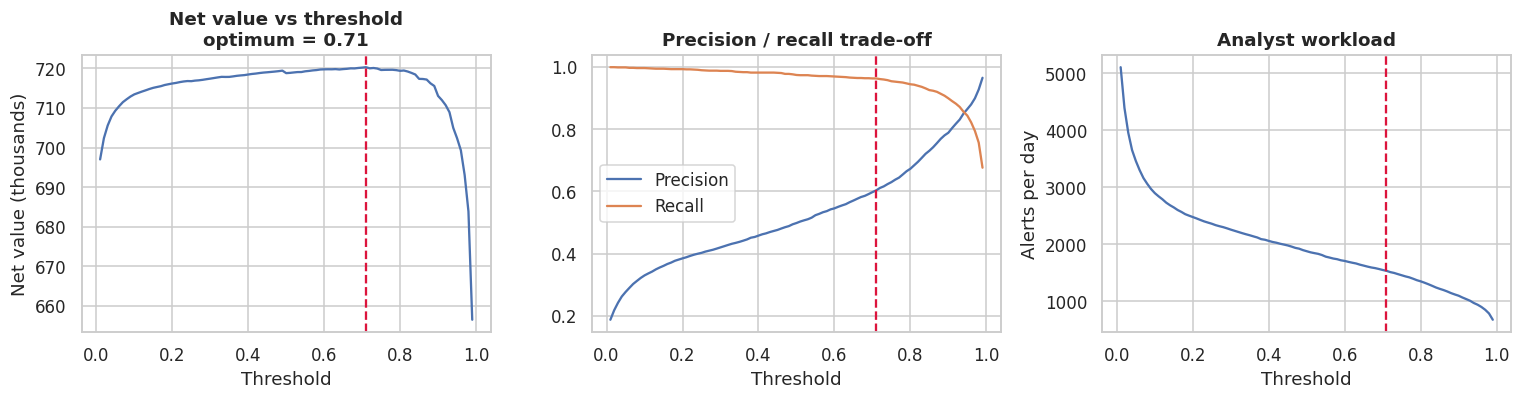

Cost-optimal threshold: 0.71 (net value 720,267 currency units)
At 0.50 default threshold, net value would be 718,768


In [19]:
amounts_test = test.amount.values

def net_value(threshold):
    flagged = y_scores >= threshold
    caught_value = amounts_test[flagged & (y_test == 1)].sum()
    review_cost = flagged.sum() * REVIEW_COST
    return caught_value - review_cost

grid = np.linspace(0.01, 0.99, 99)
value = np.array([net_value(t) for t in grid])
best_thr = float(grid[value.argmax()])

alerts = np.array([(y_scores >= t).sum() for t in grid])
recall = np.array([((y_scores >= t) & (y_test == 1)).sum() / y_test.sum() for t in grid])
precision = np.array([((y_scores >= t) & (y_test == 1)).sum() / max((y_scores >= t).sum(), 1)
                      for t in grid])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(grid, value/1000); ax[0].axvline(best_thr, ls="--", c="crimson")
ax[0].set_title(f"Net value vs threshold\noptimum = {best_thr:.2f}")
ax[0].set_xlabel("Threshold"); ax[0].set_ylabel("Net value (thousands)")

ax[1].plot(grid, precision, label="Precision"); ax[1].plot(grid, recall, label="Recall")
ax[1].axvline(best_thr, ls="--", c="crimson"); ax[1].legend()
ax[1].set_title("Precision / recall trade-off"); ax[1].set_xlabel("Threshold")

ax[2].plot(grid, alerts / ((df.step.max()+1-SPLIT_STEP)/24))
ax[2].axvline(best_thr, ls="--", c="crimson")
ax[2].set_title("Analyst workload"); ax[2].set_xlabel("Threshold"); ax[2].set_ylabel("Alerts per day")
plt.savefig(f"{FIG_DIR}/06_threshold.png", bbox_inches="tight"); plt.show()

print(f"Cost-optimal threshold: {best_thr:.2f} (net value {value.max():,.0f} currency units)")
print(f"At 0.50 default threshold, net value would be {net_value(0.5):,.0f}")

              precision    recall  f1-score   support

      Benign     0.9996    0.9931    0.9963    131791
       Fraud     0.6036    0.9632    0.7421      1440

    accuracy                         0.9928    133231
   macro avg     0.8016    0.9781    0.8692    133231
weighted avg     0.9953    0.9928    0.9936    133231

True positives (fraud caught) : 1,387
False negatives (fraud missed): 53
False positives (false alarms): 911
Alert precision: 60.36% | Fraud recall: 96.32%
Share of all transactions flagged for review: 1.725%


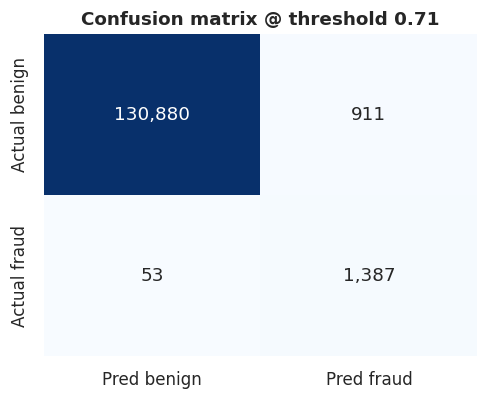

In [20]:
# ---- Performance at the chosen operating point -------------------------------------
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (y_scores >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(classification_report(y_test, y_pred, target_names=["Benign", "Fraud"], digits=4))
print(f"True positives (fraud caught) : {tp:,}")
print(f"False negatives (fraud missed): {fn:,}")
print(f"False positives (false alarms): {fp:,}")
print(f"Alert precision: {tp/(tp+fp):.2%} | Fraud recall: {tp/(tp+fn):.2%}")
print(f"Share of all transactions flagged for review: {(tp+fp)/len(y_test):.3%}")

fig, ax = plt.subplots(figsize=(4.6, 3.8))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred benign", "Pred fraud"], yticklabels=["Actual benign", "Actual fraud"])
ax.set_title(f"Confusion matrix @ threshold {best_thr:.2f}")
plt.savefig(f"{FIG_DIR}/07_confusion.png", bbox_inches="tight"); plt.show()

## 10. Model interpretation

Two views, because they answer different questions. Gain importance answers "what does the model
rely on globally". SHAP answers "why was this transaction flagged", which is what an analyst
reviewing an alert actually needs, and what a regulator will ask for.

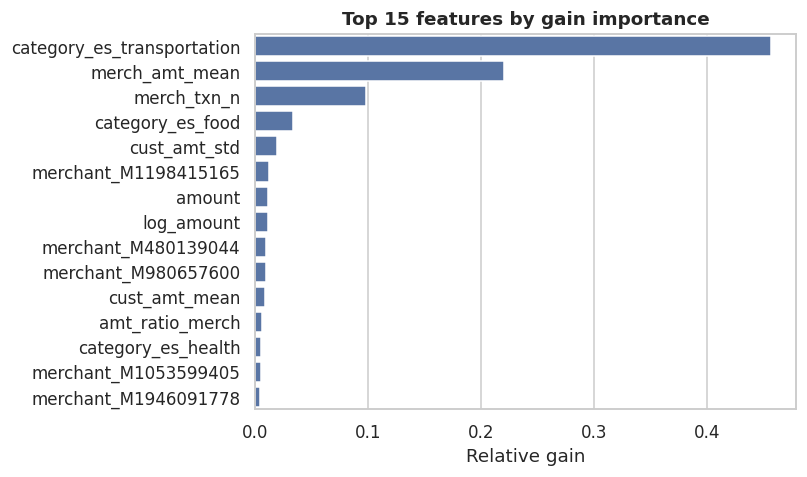

category_es_transportation    0.456565
merch_amt_mean                0.220755
merch_txn_n                   0.098355
category_es_food              0.033257
cust_amt_std                  0.019457
merchant_M1198415165          0.012800
amount                        0.011334
log_amount                    0.011177
merchant_M480139044           0.009877
merchant_M980657600           0.009640
cust_amt_mean                 0.008599
amt_ratio_merch               0.006162
category_es_health            0.005711
merchant_M1053599405          0.005143
merchant_M1946091778          0.004659


In [21]:
imp = (pd.Series(final_model.feature_importances_, index=FEATURE_NAMES)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(y=imp.index, x=imp.values, ax=ax)
ax.set_title("Top 15 features by gain importance"); ax.set_xlabel("Relative gain"); ax.set_ylabel("")
plt.savefig(f"{FIG_DIR}/08_importance.png", bbox_inches="tight"); plt.show()
print(imp.to_string())

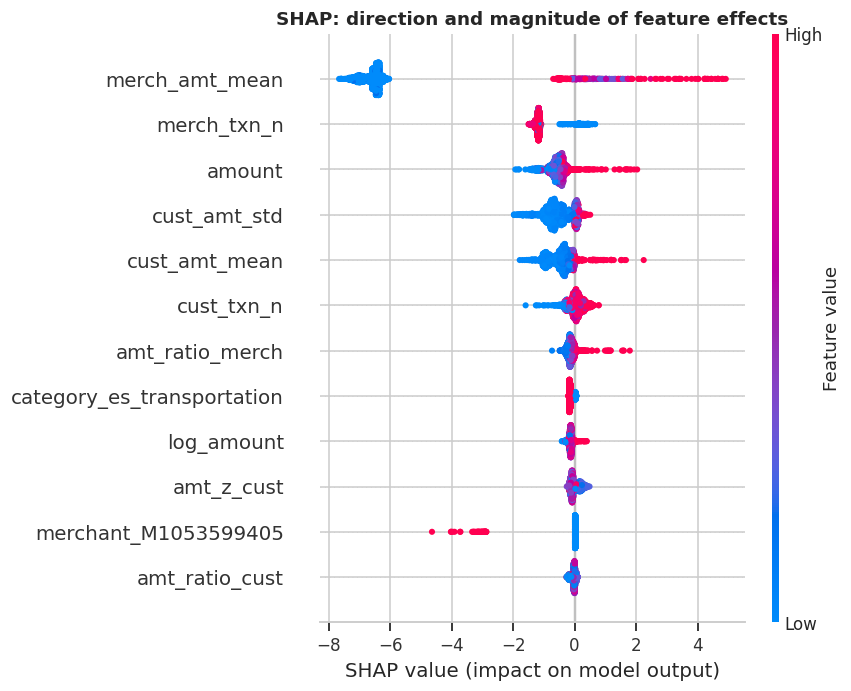

In [22]:
# ---- SHAP: per-transaction explanations --------------------------------------------
import shap

sample_idx = np.random.choice(len(X_test), size=3000, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=12, show=False)
plt.title("SHAP: direction and magnitude of feature effects", fontweight="bold")
plt.savefig(f"{FIG_DIR}/09_shap_summary.png", bbox_inches="tight"); plt.show()

In [23]:
# ---- Explaining a single alert (what an analyst would see) --------------------------
flagged_idx = np.where((y_scores >= best_thr) & (y_test == 1))[0]
case = flagged_idx[0]
case_row = X_test.iloc[[case]]
case_shap = explainer.shap_values(case_row)[0]

contrib = (pd.Series(case_shap, index=FEATURE_NAMES)
             .sort_values(key=abs, ascending=False).head(8))
print(f"Alert on transaction index {case}: "
      f"amount {test.amount.iloc[case]:.2f}, category {test.category.iloc[case]}, "
      f"score {y_scores[case]:.3f}\n")
print("Top drivers of this decision (positive pushes toward fraud):")
print(contrib.to_string())

Alert on transaction index 446: amount 384.42, category es_leisure, score 0.999

Top drivers of this decision (positive pushes toward fraud):
merch_amt_mean     4.577916
amount             1.489128
cust_txn_n        -0.612357
cust_amt_mean      0.550249
log_amount         0.307976
cust_amt_std       0.278801
merch_txn_n        0.235956
amt_ratio_merch    0.204557


## 11. Business outcomes

Translating the confusion matrix into the numbers a business reader cares about: exposure prevented,
exposure still leaking, and the review workload required to get there. All figures are for the
two-day test window and scale linearly to a full month.

In [24]:
DAYS_TEST = (df.step.max() + 1 - SPLIT_STEP) / 24
flagged = y_scores >= best_thr

caught_value = amounts_test[flagged & (y_test == 1)].sum()
missed_value = amounts_test[~flagged & (y_test == 1)].sum()
total_value = amounts_test[y_test == 1].sum()
review_cost = flagged.sum() * REVIEW_COST

summary = pd.DataFrame([
    ("Fraudulent transactions in window", f"{int(y_test.sum()):,}"),
    ("Fraud value at risk", f"{total_value:,.0f}"),
    ("Fraud value prevented", f"{caught_value:,.0f} ({caught_value/total_value:.1%})"),
    ("Fraud value still leaking", f"{missed_value:,.0f} ({missed_value/total_value:.1%})"),
    ("Alerts raised", f"{int(flagged.sum()):,}"),
    ("Alerts per day", f"{flagged.sum()/DAYS_TEST:,.0f}"),
    ("Alert precision", f"{tp/(tp+fp):.1%}"),
    ("Review cost in window", f"{review_cost:,.0f}"),
    ("Net value in window", f"{caught_value-review_cost:,.0f}"),
    ("Net value, monthly run rate", f"{(caught_value-review_cost)*30/DAYS_TEST:,.0f}"),
], columns=["Metric", "Value"])
display(summary)

# Where the remaining leakage sits, so review policy can be targeted
missed = test.loc[(~flagged) & (y_test == 1)]
by_cat = (missed.groupby("category").amount.agg(cases="size", value="sum")
            .sort_values("value", ascending=False).head(6))
print("Missed fraud by category (largest exposure first):")
print(by_cat.to_string())

,Metric,Value
0,Fraudulent transactions in window,"1,440"
1,Fraud value at risk,"735,307"
2,Fraud value prevented,"731,757 (99.5%)"
3,Fraud value still leaking,"3,550 (0.5%)"
4,Alerts raised,"2,298"
5,Alerts per day,"1,532"
6,Alert precision,60.4%
7,Review cost in window,"11,490"
8,Net value in window,"720,267"
9,"Net value, monthly run rate","14,405,342"


Missed fraud by category (largest exposure first):
                       cases        value
category                                 
es_wellnessandbeauty      26  1435.560059
es_health                  5   901.520020
es_hyper                   8   376.190002
es_barsandrestaurants      4   299.760010
es_otherservices           3   179.490005
es_sportsandtoys           1   122.669998


In [25]:
# ---- Simple rules baseline, for context --------------------------------------------
# EDA showed three categories with zero fraud covering most of the volume. A trivial
# filter would remove them; this quantifies how much the model adds over such a rule.
low_risk = ["es_transportation", "es_food", "es_contents"]
rule_flag = (~test.category.isin(low_risk)) & (test.amount > 200)
rule_tp = int((rule_flag & (y_test == 1)).sum())
rule_fp = int((rule_flag & (y_test == 0)).sum())

print(f"Rule (risky category AND amount > 200): "
      f"recall {rule_tp/y_test.sum():.1%}, precision {rule_tp/max(rule_tp+rule_fp,1):.1%}, "
      f"{rule_flag.sum():,} alerts")
print(f"Model at threshold {best_thr:.2f}:          "
      f"recall {tp/(tp+fn):.1%}, precision {tp/(tp+fp):.1%}, {int(flagged.sum()):,} alerts")

Rule (risky category AND amount > 200): recall 66.2%, precision 60.3%, 1,583 alerts
Model at threshold 0.71:          recall 96.3%, precision 60.4%, 2,298 alerts


## 12. Save artifacts

In [26]:
import joblib

joblib.dump({"model": final_model, "features": FEATURE_NAMES,
             "aggregates": agg, "threshold": best_thr},
            f"{OUT_DIR}/fraud_model.joblib")

metrics = {
    "dataset": {"rows": int(len(df)), "fraud_rate": float(df.fraud.mean()),
                "split_step": SPLIT_STEP},
    "best_params": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v))
                    for k, v in search.best_params_.items()},
    "test_metrics": {"pr_auc": float(average_precision_score(y_test, y_scores)),
                     "roc_auc": float(roc_auc_score(y_test, y_scores)),
                     "threshold": best_thr,
                     "precision": float(tp/(tp+fp)), "recall": float(tp/(tp+fn)),
                     "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)},
    "business": {"fraud_value_prevented": float(caught_value),
                 "fraud_value_missed": float(missed_value),
                 "alerts_per_day": float(flagged.sum()/DAYS_TEST),
                 "review_cost_assumption": REVIEW_COST},
    "leakage_check": {"random_split_pr_auc": float(ap_leak),
                      "temporal_split_pr_auc": float(ap_time)},
}
with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

final_table.to_csv(f"{OUT_DIR}/model_comparison.csv", index=False)
print("Saved:", sorted(os.listdir(OUT_DIR)))
print("Figures:", sorted(os.listdir(FIG_DIR)))

Saved: ['figures', 'fraud_model.joblib', 'metrics.json', 'model_comparison.csv']
Figures: ['01_class_balance.png', '02_amount.png', '03_category.png', '04_time_demo.png', '05_model_comparison.png', '06_threshold.png', '07_confusion.png', '08_importance.png', '09_shap_summary.png']


In [27]:
!zip -r outputs.zip outputs/

  adding: outputs/ (stored 0%)
  adding: outputs/metrics.json (deflated 49%)
  adding: outputs/model_comparison.csv (deflated 44%)
  adding: outputs/fraud_model.joblib (deflated 71%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/08_importance.png (deflated 16%)
  adding: outputs/figures/03_category.png (deflated 19%)
  adding: outputs/figures/09_shap_summary.png (deflated 8%)
  adding: outputs/figures/06_threshold.png (deflated 8%)
  adding: outputs/figures/02_amount.png (deflated 8%)
  adding: outputs/figures/01_class_balance.png (deflated 11%)
  adding: outputs/figures/05_model_comparison.png (deflated 9%)
  adding: outputs/figures/04_time_demo.png (deflated 11%)
  adding: outputs/figures/07_confusion.png (deflated 11%)


## Findings and recommendations

### Model performance (temporal test set, days 6 to 7, 133,231 transactions)

| Model | PR-AUC | ROC-AUC | Best F1 |
|---|---|---|---|
| Logistic Regression | 0.8778 | 0.9945 | 0.809 |
| LightGBM | 0.9138 | 0.9978 | 0.827 |
| XGBoost (default params) | 0.9206 | 0.9986 | 0.842 |
| Random Forest | 0.9249 | 0.9987 | 0.845 |
| **XGBoost (tuned)** | **0.9352** | **0.9989** | **0.855** |

Notice how little ROC-AUC separates these models (0.9945 to 0.9989) while PR-AUC spreads across six
points. That is the imbalance effect, and the reason PR-AUC is the metric of record here.

### At the selected operating point (threshold 0.71)

- Fraud recall **96.3%** (1,387 of 1,440 cases caught, 53 missed)
- Alert precision **60.4%** (911 false alarms)
- **1.72%** of all transactions flagged, roughly 1,530 alerts per day
- Fraud value prevented **731,757** of 735,307 at risk, **99.5%** of exposure
- Value still leaking **3,550**, concentrated in low-value wellness, health and hyper transactions

The gap between 96.3% of *cases* caught and 99.5% of *value* protected is not an accident: the model
misses small transactions and catches large ones, which is the right failure mode for a fraud system.

### What the analysis established

1. **Fraud is highly concentrated.** Three categories covering 89.5% of transaction volume contain
   zero fraud; leisure and travel run at 95% and 79% fraud rates. Ten of 50 merchants account for
   75% of all fraud cases.
2. **Amount is the second signal.** Median fraudulent amount is about 12x the median benign amount,
   and relative-spend features (amount versus the customer's and merchant's own baseline) rank high
   under SHAP.
3. **Gain importance and SHAP disagree, and SHAP is the more honest view.** Gain ranks
   `category_es_transportation` first because one early split discards 85% of the data cheaply.
   SHAP, which measures contribution to individual predictions, puts merchant and customer spending
   baselines first and pushes that category flag well down the list. The model is doing more than
   filtering on category, but merchant identity remains the backbone of its decisions.
4. **Demographics are close to useless.** Fraud rates by age band sit between 0.97% and 1.96% with
   no monotonic pattern, and the gender gap (1.47% female vs 0.91% male) is too weak to build policy
   on. Hour of day varies only between 1.19% and 1.24%, so it carries almost no signal either. Using
   demographic attributes to drive fraud decisions also carries obvious fairness and regulatory
   exposure, which is a stronger reason to leave them out of any deployed version.
5. **SMOTE added nothing.** Cost-sensitive learning via `scale_pos_weight` matched it (0.9206 vs
   0.9205 PR-AUC) at a third of the training data volume. The recommendation is to skip synthetic
   oversampling here and keep class weighting.
6. **A random split would have overstated performance** by 0.011 PR-AUC (0.9339 vs 0.9226). Small in
   this synthetic dataset, but the mechanism is real and grows with customer-level features, so the
   temporal split is the defensible protocol.
7. **The threshold is not a delicate choice.** Net value stays within about 1% of its maximum across
   thresholds 0.4 to 0.8, because the average fraudulent transaction is worth roughly 510 while a
   review is assumed to cost 5. At a 100:1 ratio the economics say chase recall. That conclusion
   only flips if review cost per alert rises toward the value of the fraud it prevents.

### Recommendations

1. **Deploy in shadow mode first**, scoring live transactions without blocking, for two to four
   weeks. Compare alert volume and precision against the current process before any customer-facing
   action.
2. **Tier the response by score** rather than using a single cut. High band (above 0.90) is a hard
   block or step-up authentication; middle band (0.60 to 0.90) is analyst review; below that,
   monitor only. This concentrates the 60% precision where being wrong is expensive.
3. **Confirm the review cost per alert.** It is the single input that decides the operating
   threshold, and it is currently an assumption in this notebook, not a measured figure. At roughly
   1,530 alerts per day, review capacity is the real constraint on deployment.
4. **Add velocity features before production.** Transactions per customer in the last hour, day and
   week, plus time since previous transaction, are standard fraud signals that this 7.5 day window
   is too short to support. Expect a further recall gain from them.
5. **Monitor for drift and retrain monthly.** Fraud rate already drifts within this sample (1.52%
   on day 0 down to 1.07% on day 7). Alert on PR-AUC decay, alert volume shifts, and score
   distribution changes.
6. **Ship SHAP explanations with every alert.** Analysts work faster with reasons attached, and
   per-decision explanations are what an auditor or regulator will ask for.

### Honest limitations

- This is the BankSim **synthetic** dataset. Real fraud is noisier, adversarial, and drifts as
  attackers adapt. Treat 0.94 PR-AUC as an upper bound on what this feature set achieves in
  production, not as a forecast.
- Merchant identity carries much of the model's weight. That works while the merchant mix is stable,
  but it degrades against a new merchant with no history, and it is a thin basis for a production
  system. Recommendation 4 is the direct answer to this.
- One origin zip code and one merchant zip code across the whole file means no geographic or
  cross-border signal exists here. Distance and country mismatch features are usually strong in
  real card fraud.
- Only 7.5 days of history. No weekly seasonality, no established customer history, no velocity
  windows longer than a day.
- No labelling delay is modelled. In production, fraud labels arrive days or weeks after the
  transaction via chargebacks, which constrains how often the model can honestly be retrained.